# Three-point finite differences for $-u''=f$
The interval is $(0,1)$, with $u(0)=u(1)=0$ and $h=1/(N+1)$. The listed exact solutions determine $f$. For problem 4, subtracting $1/8$ makes both boundary values zero. The bound for problem 4 applies to odd $N$, where $x=1/2$ is a grid point.

In [7]:
N_VALUES = [15, 31, 63, 127,255,511,1023]
import matplotlib.pyplot as plt
import numpy as np


def solve_poisson(n, rhs):
    """Solve (2u_i-u_{i-1}-u_{i+1})/h**2 = f(x_i)."""
    h = 1.0 / (n + 1)
    x = h * np.arange(1, n + 1)
    diagonal = np.full(n, 2.0)
    upper = np.full(n - 1, -1.0)
    b = h * h * rhs(x)

    # Thomas algorithm for the tridiagonal matrix; boundary values are zero.
    for i in range(1, n):
        factor = -1.0 / diagonal[i - 1]
        diagonal[i] -= factor * upper[i - 1]
        b[i] -= factor * b[i - 1]
    u = np.empty(n)
    u[-1] = b[-1] / diagonal[-1]
    for i in range(n - 2, -1, -1):
        u[i] = (b[i] - upper[i] * u[i + 1]) / diagonal[i]
    return x, u


CASES = {
    "quadratic": (
        lambda x: x * (1 - x),
        lambda x: np.full_like(x, 2.0),
        lambda h: 0.0,
    ),
    "quartic": (
        lambda x: x**4 - x,
        lambda x: -12 * x**2,
        lambda h: h**2 / 4,
    ),
    "cosine": (
        lambda x: 1 - np.cos(2 * np.pi * x),
        lambda x: -4 * np.pi**2 * np.cos(2 * np.pi * x),
        lambda h: np.pi**4 * h**2 / 6,
    ),
    "absolute_cubic": (
        lambda x: np.abs(x - 0.5) ** 3 - 0.125,
        lambda x: -6 * np.abs(x - 0.5),
        lambda h: h**2 / 2,
    ),
}


def evaluate_case(name, mesh_sizes):
    """Return (case, N, h, maximum error, observed rate, bound) rows."""
    exact, rhs, bound = CASES[name]
    rows = []
    previous = None
    for n in sorted(mesh_sizes):
        h = 1 / (n + 1)
        x, numeric = solve_poisson(n, rhs)
        error = float(np.max(np.abs(numeric - exact(x))))
        rate = (np.log(previous[1] / error) / np.log(previous[0] / h)
                if name != "quadratic" and previous is not None
                and error > 0 and previous[1] > 0 else float("nan"))
        predicted = bound(h) if name != "absolute_cubic" or n % 2 else float("nan")
        rows.append((name, n, h, error, rate, predicted))
        previous = (h, error)
    return rows


def print_table(rows, title):
    print(f"\n{title}\n{'=' * len(title)}")
    print(f"{'Case':<17} {'N':>5} {'h':>11} {'L_inf error':>14} {'Rate':>9} {'Bound':>14}")
    print("-" * 77)
    for name, n, h, error, rate, bound in rows:
        rate_text = f"{rate:.4f}" if np.isfinite(rate) else "—"
        bound_text = f"{bound:.6e}" if np.isfinite(bound) else "—"
        print(f"{name:<17} {n:>5} {h:>11.6f} {error:>14.6e} "
              f"{rate_text:>9} {bound_text:>14}")


def plot_errors(rows, output=None):
    """Display the plot in a notebook, or save it when output is given."""
    fig, ax = plt.subplots(figsize=(7, 5))
    for name in CASES:
        if name == "quadratic":
            continue  # Its discretization error is exactly zero.
        points = [(h, error) for case, _, h, error, _, _ in rows if case == name]
        ax.loglog(*zip(*points), marker="o", label=name)
    hs = np.array(sorted({h for _, _, h, _, _, _ in rows}))
    ax.loglog(hs, hs**2, "k--", label=r"reference $h^2$")
    ax.set(xlabel="mesh spacing h", ylabel=r"maximum error $\|u_h-u\|_\infty$",
           title="Three-point Poisson finite-difference error")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    if output is None:
        plt.show()
    else:
        fig.savefig(output, dpi=180)
        plt.close(fig)



## Problem 1: $u(x)=x(1-x)$, $f(x)=2$

In [8]:
problem_1 = evaluate_case('quadratic', N_VALUES)
print_table(problem_1, 'Problem 1: quadratic')


Problem 1: quadratic
Case                  N           h    L_inf error      Rate          Bound
-----------------------------------------------------------------------------
quadratic            15    0.062500   2.775558e-17         —   0.000000e+00
quadratic            31    0.031250   7.771561e-16         —   0.000000e+00
quadratic            63    0.015625   2.386980e-15         —   0.000000e+00
quadratic           127    0.007812   2.386980e-15         —   0.000000e+00
quadratic           255    0.003906   8.881784e-15         —   0.000000e+00
quadratic           511    0.001953   1.987299e-14         —   0.000000e+00
quadratic          1023    0.000977   9.123258e-14         —   0.000000e+00


## Problem 2: $u(x)=x^4-x$, $f(x)=-12x^2$

In [9]:
problem_2 = evaluate_case('quartic', N_VALUES)
print_table(problem_2, 'Problem 2: quartic')


Problem 2: quartic
Case                  N           h    L_inf error      Rate          Bound
-----------------------------------------------------------------------------
quartic              15    0.062500   9.765625e-04         —   9.765625e-04
quartic              31    0.031250   2.441406e-04    2.0000   2.441406e-04
quartic              63    0.015625   6.103516e-05    2.0000   6.103516e-05
quartic             127    0.007812   1.525879e-05    2.0000   1.525879e-05
quartic             255    0.003906   3.814697e-06    2.0000   3.814697e-06
quartic             511    0.001953   9.536743e-07    2.0000   9.536743e-07
quartic            1023    0.000977   2.384187e-07    2.0000   2.384186e-07


## Problem 3: $u(x)=1-\cos(2\pi x)$, $f(x)=-4\pi^2\cos(2\pi x)$

In [10]:
problem_3 = evaluate_case('cosine', N_VALUES)
print_table(problem_3, 'Problem 3: cosine')


Problem 3: cosine
Case                  N           h    L_inf error      Rate          Bound
-----------------------------------------------------------------------------
cosine               15    0.062500   2.590149e-02         —   6.341738e-02
cosine               31    0.031250   6.437929e-03    2.0084   1.585434e-02
cosine               63    0.015625   1.607155e-03    2.0021   3.963586e-03
cosine              127    0.007812   4.016436e-04    2.0005   9.908965e-04
cosine              255    0.003906   1.004018e-04    2.0001   2.477241e-04
cosine              511    0.001953   2.509989e-05    2.0000   6.193103e-05
cosine             1023    0.000977   6.274936e-06    2.0000   1.548276e-05


## Problem 4: $u(x)=|x-1/2|^3-1/8$, $f(x)=-6|x-1/2|$

In [11]:
problem_4 = evaluate_case('absolute_cubic', N_VALUES)
print_table(problem_4, 'Problem 4: absolute cubic')


Problem 4: absolute cubic
Case                  N           h    L_inf error      Rate          Bound
-----------------------------------------------------------------------------
absolute_cubic       15    0.062500   1.953125e-03         —   1.953125e-03
absolute_cubic       31    0.031250   4.882813e-04    2.0000   4.882812e-04
absolute_cubic       63    0.015625   1.220703e-04    2.0000   1.220703e-04
absolute_cubic      127    0.007812   3.051758e-05    2.0000   3.051758e-05
absolute_cubic      255    0.003906   7.629395e-06    2.0000   7.629395e-06
absolute_cubic      511    0.001953   1.907349e-06    2.0000   1.907349e-06
absolute_cubic     1023    0.000977   4.768372e-07    2.0000   4.768372e-07


## Final table and error graph


Final table: all problems
Case                  N           h    L_inf error      Rate          Bound
-----------------------------------------------------------------------------
quadratic            15    0.062500   2.775558e-17         —   0.000000e+00
quadratic            31    0.031250   7.771561e-16         —   0.000000e+00
quadratic            63    0.015625   2.386980e-15         —   0.000000e+00
quadratic           127    0.007812   2.386980e-15         —   0.000000e+00
quadratic           255    0.003906   8.881784e-15         —   0.000000e+00
quadratic           511    0.001953   1.987299e-14         —   0.000000e+00
quadratic          1023    0.000977   9.123258e-14         —   0.000000e+00
quartic              15    0.062500   9.765625e-04         —   9.765625e-04
quartic              31    0.031250   2.441406e-04    2.0000   2.441406e-04
quartic              63    0.015625   6.103516e-05    2.0000   6.103516e-05
quartic             127    0.007812   1.525879e-05    2.000

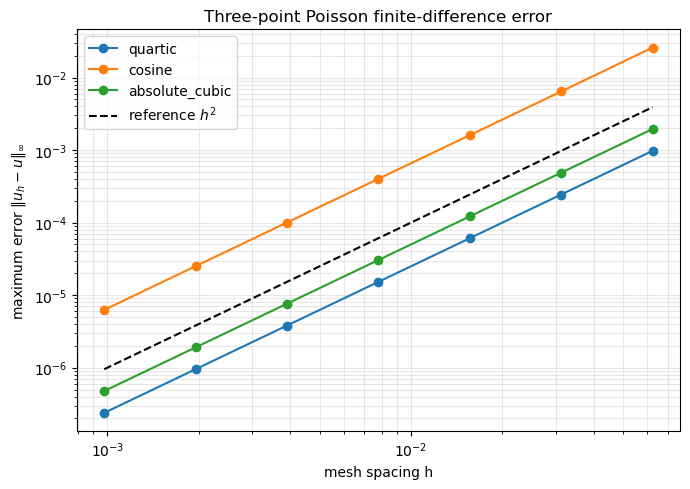

In [12]:
all_results = problem_1 + problem_2 + problem_3 + problem_4
print_table(all_results, 'Final table: all problems')
plot_errors(all_results)